In [12]:

# Pandas is used for reading and manipulating datasets
import pandas as pd
import matplotlib.pyplot as plt

# NumPy helps with numerical computations
import numpy as np

df = pd.read_csv("/content/Dataset 2.csv")
# Display first 5 rows
print(df.head())
print(df.columns)
int_columns = [i for i in df.columns if pd.api.types.is_numeric_dtype(df[i])]
string_columns = [i for i in df.columns if not pd.api.types.is_numeric_dtype(df[i])]
print(df.isna().sum())


   UserID  Age  Gender SubscriptionType  WatchHoursPerWeek  DevicesUsed  \
0    1001   22  Female            Basic                 23            5   
1    1002   55    Male            Basic                  9            4   
2    1003   49    Male            Basic                  8            3   
3    1004   39  Female          Premium                 19            5   
4    1005   38  Female          Premium                 23            5   

  FavoriteGenre  AdClicks  MonthlySpend SubscriptionRenewed  
0        Comedy        13           353                  No  
1         Drama        14           317                 Yes  
2        Comedy        16           309                  No  
3         Drama        45           833                 Yes  
4        Sci-Fi        24           804                 Yes  
Index(['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek',
       'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend',
       'SubscriptionRenewed'],
    

In [13]:
# 1. Calculate means (fixed the trailing space in MonthlySpend)
print(df["Age"].mean())
print(df["WatchHoursPerWeek"].mean())
print(df["MonthlySpend"].mean())

# 2. Group by Subscription Type and count rows
print(df.groupby("SubscriptionType")["SubscriptionType"].count())
print(df.groupby("SubscriptionRenewed")["SubscriptionRenewed"].agg(lambda x: len(x) / df["SubscriptionRenewed"].size))


41.824
14.236
689.9053333333334
SubscriptionType
Basic      342
Premium    279
VIP        129
Name: SubscriptionType, dtype: int64
SubscriptionRenewed
No     0.537333
Yes    0.462667
Name: SubscriptionRenewed, dtype: float64


In [14]:
# Used to split dataset into training and testing data
from sklearn.model_selection import train_test_split

# Used to evaluate classification models
from sklearn.metrics import accuracy_score, confusion_matrix

# Converts text columns into numerical values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['SubscriptionType'] = le.fit_transform(df['SubscriptionType'])
df['Gender'] = le.fit_transform(df['Gender'])
df['FavoriteGenre'] = le.fit_transform(df['FavoriteGenre'])
df['SubscriptionRenewed'] = le.fit_transform(df['SubscriptionRenewed'])

#no-0 yes-1
#basix-0 preimium -1 3

                       UserID       Age    Gender  SubscriptionType  \
UserID               1.000000  0.026966  0.037422          0.016045   
Age                  0.026966  1.000000  0.031877         -0.049154   
Gender               0.037422  0.031877  1.000000         -0.021340   
SubscriptionType     0.016045 -0.049154 -0.021340          1.000000   
WatchHoursPerWeek    0.054368 -0.037906 -0.019450          0.074907   
DevicesUsed          0.054994  0.017861 -0.025717         -0.026392   
FavoriteGenre       -0.001642  0.078355 -0.019869          0.044017   
AdClicks            -0.009487  0.007101 -0.052484         -0.080187   
MonthlySpend         0.018696 -0.054793 -0.018173          0.974986   
SubscriptionRenewed  0.036418  0.005467  0.031094          0.161020   

                     WatchHoursPerWeek  DevicesUsed  FavoriteGenre  AdClicks  \
UserID                        0.054368     0.054994      -0.001642 -0.009487   
Age                          -0.037906     0.017861       

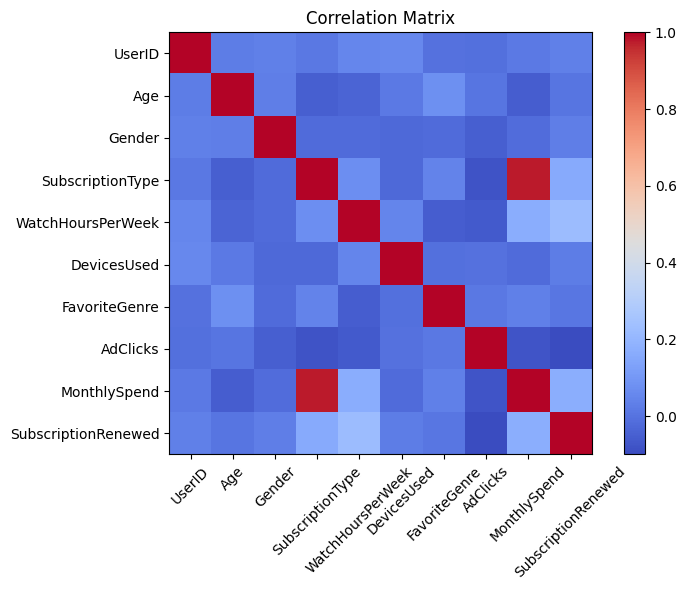

In [15]:
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

# Plot correlation matrix
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()


plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [16]:
# Machine Learning Algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# SYNTAX FIX: Added the missing comma between "Age" and "Gender"
X = df.drop(["UserID", "Age", "Gender", "DevicesUsed","" "FavoriteGenre", "AdClicks", "SubscriptionRenewed","SubscriptionType"], axis=1)

y = df['SubscriptionRenewed']

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and train the model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict and evaluate
pred = dt.predict(X_test)

print('Decision Tree Accuracy:', accuracy_score(y_test, pred))

print('\nConfusion Matrix')
print(confusion_matrix(y_test, pred))


Decision Tree Accuracy: 0.5066666666666667

Confusion Matrix
[[44 38]
 [36 32]]


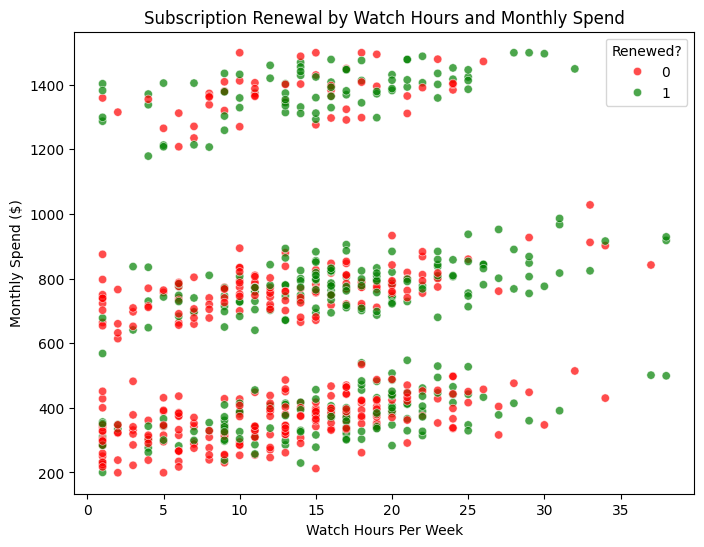

KNN Accuracy: 0.6


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier

# 1. Create the scatter plot with Yes/No labels
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="WatchHoursPerWeek",
    y="MonthlySpend",
    hue="SubscriptionRenewed",  # This splits colors by Yes/No
    palette={1: "green", 0: "red"},  # Custom colors
    alpha=0.7
)

plt.title("Subscription Renewal by Watch Hours and Monthly Spend")
plt.xlabel("Watch Hours Per Week")
plt.ylabel("Monthly Spend ($)")
plt.legend(title="Renewed?")
plt.show()

# 2. Setup your KNN Classifier
# (Make sure to only feed numerical features into X)
X = df[["WatchHoursPerWeek", "MonthlySpend"]]
y = df["SubscriptionRenewed"]
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)

knn_pred = knn.predict(X_test)

print('KNN Accuracy:', accuracy_score(y_test,knn_pred))



In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
X_reg = df[["SubscriptionType" ,"WatchHoursPerWeek"]]
y_reg = df['MonthlySpend']

X_train_reg,X_test_reg,y_train_reg,y_test_reg = train_test_split(
    X_reg,y_reg,test_size=0.2,random_state=42
)

lr = LinearRegression()

lr.fit(X_train_reg,y_train_reg)

# 1. Predict on the test data
y_pred_reg = lr.predict(X_test_reg)

# 2. Calculate regression metrics
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print('Linear Regression Performance:')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R² Score: {r2:.2f}')


Linear Regression Performance:
Mean Squared Error (MSE): 4745.52
R² Score: 0.97


ques/ans buisness ques

1. Which factors appear to influence subscription renewal the most?
acc to corr matrix WatchHoursPerWeek  most probably the more the person likes watchhing netflix will buy it
2. Why is subscription renewal a classification problem?
because it is dicreate yes and no
3. Why is monthly spending a regression problem?
because it is contunious
4. Which algorithm performed better for renewal prediction?
the prediction of knn is better than descision tree but not as good because 0.6 is still random we need to uses better ways like using cross validation random forest or svm
5. How could the platform use these predictions to improve customer retention?
we can figureout which type of genre most renewal people like and make movies more on that  
You can also add that because WatchHoursPerWeek is so critical, the platform could trigger automated push notifications or discount offers to users whose weekly watch hours drop below the average ($14.2$ hours) to re-engage them before their subscription lapses.
